# TP4 - Solving MDPs (Learning)

**AUTHOR**: Lucía Porlán Ferrando

**SUBJECT:** Introduction to Reinforment Learning


# 1. Theoretical Introduction

In this work, we study the learning version of a sequential decision-making problem modeled as a Markov Decision Process (MDP).

An MDP is defined by:
+ A set of states, $S$.
+ A set of actions, $A$.
+ Transition dynamics $P(s'|s,a)$.
+ A reward function.
+ A discount factor $\gamma$.

In the previous assignment, the problem was solved assuming that the model was known. In that case, the transition probabilities and rewards could be directly used in order to evaluate policies and compute the optimal one.

In this assignment, we consider the same Gridworld idea, but now from a reinforcement learning perspective. The agent doesn't rely on the full model during learning, but instead interacts with the environment and updates its estimates from experience.

Two main problems will be addressed:
1. Performance Prediction: learning the value function $V^{\pi}(s)$ of a fixed policy.
2. Control: learning the optimal policy from interaction.

For prediction, the following methods will be used:
+ Monte Carlo First Visit
+ Monte Carlo Every Visit
+ TD(0)

For control, the following methods will be used:
+ SARSA, which is an on-policy method
+ Q-learning, which is an off-policy method

Monte Carlo methods estimate the value of a state from complete returns observed in full episodes. TD(0) updates the value estimate after each transition by bootstrapping from the next estimated value. SARSA updates action-values using the action actually selected by the current exploratory policy, whereas Q-learning updates toward the greedy maximum over next actions.

The objective of the work is to compare these methods, verify that the prediction methods converge to the correct value function, and analyze the policies learned by SARSA and Q-learning under different parameter choices.

# 2. Environment Description

The environment is a Gridworld of 3 rows by 4 columns.

It consists of:
+ Normal states with reward -0.04
+ Terminal states
+ One inaccessible cell

The possible actions are:
+ 0: Up
+ 1: Right
+ 2: Down
+ 3: Left

The dynamics are stochastic. If the agent chooses an action, the intended direction is executed with probability 0.4, while each of the other three directions occurs with probability 0.2.

If a movement hits a wall or the blocked cell, the agent remains in the same state.

The discount factor is $\gamma = 0.9$.

In this assignment, when a terminal state is reached, the episode ends for Monte Carlo methods. For the continuing-learning interpretation, the environment is restarted from one of the non-terminal states, as indicated in the statement.

# 3. Environment Definition

## 3.1. Libraries

In [88]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

## 3.2. State Matrix

Convention:
+ 0 $\rightarrow$ normal state
+ 1 $\rightarrow$ terminal state
+ -1 $\rightarrow$ blocked state

In [89]:
state_matrix = np.zeros((3, 4))
state_matrix[0, 3] = 1
state_matrix[1, 3] = 1
state_matrix[1, 1] = -1

print("State Matrix:")
print(state_matrix)

State Matrix:
[[ 0.  0.  0.  1.]
 [ 0. -1.  0.  1.]
 [ 0.  0.  0.  0.]]


## 3.3. Reward Matrix

Reward Matrix:
[[-4.e-02 -4.e-02 -4.e-02  1.e+00]
 [-4.e-02 -4.e-02 -4.e-02 -1.e+02]
 [-4.e-02 -4.e-02 -4.e-02 -4.e-02]]


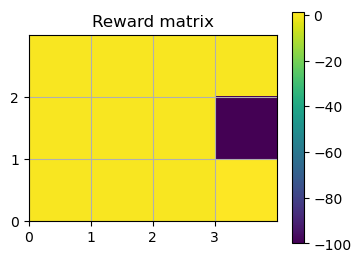

In [90]:
reward_matrix = np.full((3, 4), -0.04)
reward_matrix[0, 3] = 1.0
reward_matrix[1, 3] = -100.0

print("Reward Matrix:")
print(reward_matrix)

plt.figure(figsize=(4,3))
plt.imshow(reward_matrix, origin="lower", vmin=-100, vmax=1, extent=[0, 4, 0, 3])
plt.colorbar()
plt.title("Reward matrix")
plt.xticks(np.arange(4))
plt.yticks(np.arange(3))
plt.grid()
plt.show()

## 3.4. Given Policy

+ 0 = Up
+ 1 = Right
+ 2 = Down
+ 3 = Left
+ -1 = terminal
+ np.nan = blocked

In [91]:
policy_matrix = np.array([
    [0,      3,  3, -1],
    [3, np.nan,  3, -1],
    [3,      2,  0,  3]
], dtype=float)

print("Given Policy Matrix:")
print(policy_matrix)

Given Policy Matrix:
[[ 0.  3.  3. -1.]
 [ 3. nan  3. -1.]
 [ 3.  2.  0.  3.]]


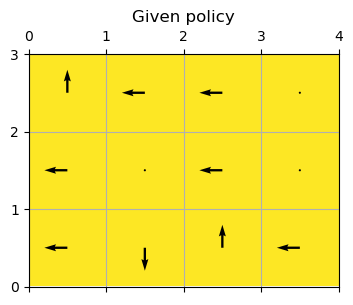

In [92]:
def print_policy(policy_matrix2, V=np.array([]), lstates=[], title = "Policy"):
    policy_matrix = policy_matrix2[::-1]
    shape = policy_matrix.shape
    U = np.zeros(shape)
    R = np.zeros(shape)

    for row in range(shape[0]):
        for col in range(shape[1]):
            val = policy_matrix[row, col]

            if val == -1:
                U[row, col] = 0
                R[row, col] = 0
            elif val == 0:
                U[row, col] = 0
                R[row, col] = 1
            elif val == 1:
                U[row, col] = 1
                R[row, col] = 0
            elif val == 2:
                U[row, col] = 0
                R[row, col] = -1
            elif val == 3:
                U[row, col] = -1
                R[row, col] = 0
            elif np.isnan(val):
                U[row, col] = 0
                R[row, col] = 0

    plt.rcParams['figure.figsize'] = (4, 3)

    if V.size == 0:
        V = np.ones(shape)
        for x in lstates:
            V[x.multi_index] = 0.7
        plt.matshow(V, extent=[0, 4, 0, 3], vmin=0, vmax=1)
    else:
        plt.matshow(V, extent=[0, 4, 0, 3])

    plt.grid()
    X, Y = np.meshgrid(np.arange(0.5, 4.5, 1), np.arange(0.5, 3.5, 1))
    plt.quiver(X, Y, U, R)
    plt.title(title)
    plt.show()

print_policy(policy_matrix, title="Given policy")

## 3.5. Transition Matrix

In [93]:
transition_matrix = np.array([
    [0.4, 0.2, 0.2, 0.2],
    [0.2, 0.4, 0.2, 0.2],
    [0.2, 0.2, 0.4, 0.2],
    [0.2, 0.2, 0.2, 0.4]
])

gamma = 0.9

print("Transition matrix:")
print(transition_matrix)
print("Gamma:", gamma)

Transition matrix:
[[0.4 0.2 0.2 0.2]
 [0.2 0.4 0.2 0.2]
 [0.2 0.2 0.4 0.2]
 [0.2 0.2 0.2 0.4]]
Gamma: 0.9


## 3.6. Auxiliary Functions

In [94]:
def is_terminal(state):
    return state_matrix[state] == 1

def is_blocked(state):
    return state_matrix[state] == -1

def is_normal(state):
    return state_matrix[state] == 0

def get_valid_states():
    valid_states = []
    for i in range(state_matrix.shape[0]):
        for j in range(state_matrix.shape[1]):
            if state_matrix[i, j] != -1:
                valid_states.append((i, j))
    return valid_states

def get_non_terminal_states():
    states = []
    for i in range(state_matrix.shape[0]):
        for j in range(state_matrix.shape[1]):
            if state_matrix[i, j] == 0:
                states.append((i, j))
    return states

def prob_next_state(position, world_row=3, world_col=4):
    """
    Returns the list of possible next states ordered as:
    [Up, Right, Down, Left]
    If the movement hits a wall or the blocked cell, the agent remains in the same state.
    """
    possible = []

    for action in range(4):
        position_def = position

        if action == 0:      # UP
            new_position = (position[0] - 1, position[1])
        elif action == 1:    # RIGHT
            new_position = (position[0], position[1] + 1)
        elif action == 2:    # DOWN
            new_position = (position[0] + 1, position[1])
        elif action == 3:    # LEFT
            new_position = (position[0], position[1] - 1)

        if 0 <= new_position[0] < world_row and 0 <= new_position[1] < world_col:
            if state_matrix[new_position] != -1:
                position_def = new_position

        possible.append(position_def)

    return possible

def sample_next_state(state, action):
    next_states = prob_next_state(state)
    probs = transition_matrix[action]
    idx = np.random.choice(4, p=probs)
    next_state = next_states[idx]
    reward = reward_matrix[next_state]
    return next_state, reward

def sample_start_state():
    non_terminal_states = get_non_terminal_states()
    idx = np.random.choice(len(non_terminal_states))
    return non_terminal_states[idx]

def state_to_index(pos):
    return pos[0] * state_matrix.shape[1] + pos[1]

def vector_to_matrix(V_vec):
    return V_vec.reshape(state_matrix.shape)

# 4. Performance Prediction

## 4.1 Theory Section

In this section, a fixed policy is evaluated.

The goal is not yet to find the optimal policy, but to estimate the value function V^pi(s), which gives the expected discounted return when following the given policy from each state.

Three model-free prediction approaches will be used:

1. Monte Carlo First Visit
2. Monte Carlo Every Visit
3. TD(0)

Monte Carlo methods estimate the value of a state using the empirical mean of the total return observed after visits to that state. In First Visit Monte Carlo, only the first occurrence of each state in an episode is used. In Every Visit Monte Carlo, all occurrences are used.

TD(0) updates the estimate after each transition according to:
V(S) <- V(S) + alpha [R + gamma V(S') - V(S)]

Thus, TD(0) learns online and uses bootstrapping.

Finally, the exact value function of the given policy will be computed using the model:
V = (I - gamma P)^(-1) R

This exact solution will be used to verify that the learning-based methods converge to the same result.

## 4.2. Episode Generation for a Fixed Policy

In [95]:
def select_action_from_policy(policy_matrix, state):
    return int(policy_matrix[state])

def generate_episode(policy_matrix, max_steps=500):
    episode = []
    state = sample_start_state()

    for _ in range(max_steps):
        if is_terminal(state):
            break

        action = select_action_from_policy(policy_matrix, state)
        next_state, reward = sample_next_state(state, action)

        episode.append((state, action, reward, next_state))
        state = next_state

        if is_terminal(state):
            break

    return episode

## 4.3. Exercise 1 - Monte Carlo First Visit and Every Visit

In [96]:
def mc_first_visit(policy_matrix, n_episodes=5000):
    V = np.zeros(state_matrix.shape)
    returns_count = np.zeros(state_matrix.shape)
    history = []

    for ep in range(1, n_episodes + 1):
        episode = generate_episode(policy_matrix)

        G = 0.0
        visited = set()

        for t in reversed(range(len(episode))):
            s, a, r, s_next = episode[t]
            G = r + gamma * G

            if s not in [x[0] for x in episode[:t]]:
                returns_count[s] += 1
                alpha = 1.0 / returns_count[s]
                V[s] += alpha * (G - V[s])

        history.append(np.mean(np.abs(V[state_matrix == 0])))

    return V, history

def mc_every_visit(policy_matrix, n_episodes=5000):
    V = np.zeros(state_matrix.shape)
    returns_count = np.zeros(state_matrix.shape)
    history = []

    for ep in range(1, n_episodes + 1):
        episode = generate_episode(policy_matrix)

        G = 0.0

        for t in reversed(range(len(episode))):
            s, a, r, s_next = episode[t]
            G = r + gamma * G

            returns_count[s] += 1
            alpha = 1.0 / returns_count[s]
            V[s] = V[s] + alpha * (G - V[s])

        history.append(np.mean(np.abs(V[state_matrix == 0])))

    return V, history

In [97]:
V_mc_first, mc_first_history = mc_first_visit(policy_matrix, n_episodes=20000)
V_mc_every, mc_every_history = mc_every_visit(policy_matrix, n_episodes=20000)

print("MC First Visit Value Function:")
print(V_mc_first)

print("MC Every Visit Value Function:")
print(V_mc_every)

MC First Visit Value Function:
[[ -4.51535631  -6.04232616 -12.07067044   0.        ]
 [ -5.44705566   0.         -44.3633714    0.        ]
 [ -8.90879403 -17.21508469 -34.69828196 -50.92382125]]
MC Every Visit Value Function:
[[ -4.43952587  -5.96925558 -12.24058126   0.        ]
 [ -5.16576743   0.         -44.40864597   0.        ]
 [ -8.74507778 -16.98753641 -34.50093774 -50.64481111]]


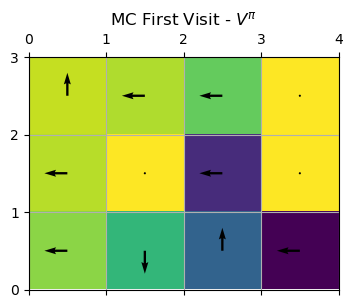

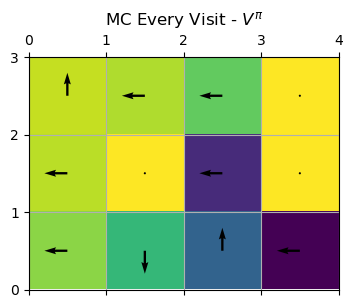

In [98]:
print_policy(policy_matrix, V_mc_first, title="MC First Visit - $V^{\pi}$")
print_policy(policy_matrix, V_mc_every, title="MC Every Visit - $V^{\pi}$")

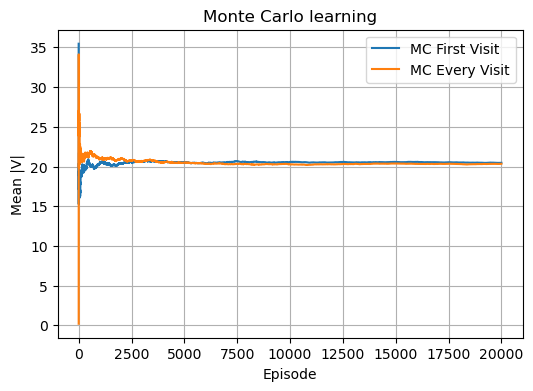

In [99]:
plt.figure(figsize=(6, 4))
plt.plot(mc_first_history, label="MC First Visit")
plt.plot(mc_every_history, label="MC Every Visit")
plt.xlabel("Episode")
plt.ylabel("Mean |V|")
plt.title("Monte Carlo learning")
plt.legend()
plt.grid()
plt.show()

## 4.4. Exercise 2 - TD(0)

In [100]:
def td_zero(policy_matrix, n_episodes=5000):
    V = np.zeros(state_matrix.shape)
    history = []

    for ep in range(1, n_episodes + 1):
        alpha = 1.0 / ep
        state = sample_start_state()

        while not is_terminal(state):
            action = select_action_from_policy(policy_matrix, state)
            next_state, reward = sample_next_state(state, action)

            td_target = reward
            if not is_terminal(next_state):
                td_target += gamma * V[next_state]

            V[state] = V[state] + alpha * (td_target - V[state])

            state = next_state

        history.append(np.mean(np.abs(V[state_matrix == 0])))

    return V, history

In [101]:
V_td, td_history = td_zero(policy_matrix, n_episodes=20000)

print("TD(0) Value Function:")
print(V_td)

TD(0) Value Function:
[[ -4.3778957   -5.90071964 -12.03000736   0.        ]
 [ -5.07364748   0.         -44.28619874   0.        ]
 [ -8.46085753 -16.49187245 -33.64788112 -49.22247598]]


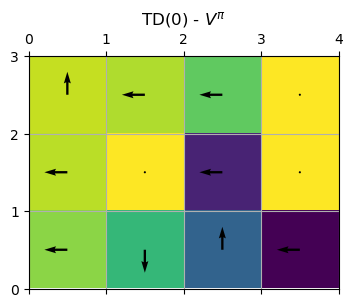

In [102]:
print_policy(policy_matrix, V_td, title="TD(0) - $V^{\pi}$")

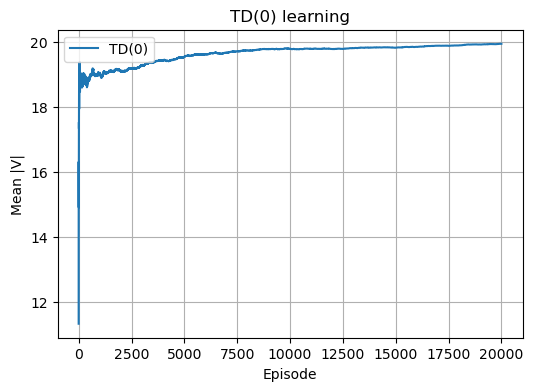

In [103]:
plt.figure(figsize=(6, 4))
plt.plot(td_history, label="TD(0)")
plt.xlabel("Episode")
plt.ylabel("Mean |V|")
plt.title("TD(0) learning")
plt.legend()
plt.grid()
plt.show()

## 4.5. Exercise 3 - Exact Verification

In [104]:
def get_P_pi(policy_matrix):
    n_states = state_matrix.shape[0] * state_matrix.shape[1]
    P = np.zeros((n_states, n_states))

    state = np.nditer(state_matrix, flags=['multi_index'])
    while not state.finished:
        s = state.multi_index
        idx = state_to_index(s)

        if state_matrix[s] == 0:
            action = int(policy_matrix[s])
            next_states = prob_next_state(s)

            for ns, p in zip(next_states, transition_matrix[action]):
                P[idx, state_to_index(ns)] += p
        else:
            P[idx, :] = 0.0

        state.iternext()

    return P

def get_R_pi(policy_matrix):
    n_states = state_matrix.shape[0] * state_matrix.shape[1]
    R_pi = np.zeros(n_states)

    state = np.nditer(state_matrix, flags=['multi_index'])
    while not state.finished:
        s = state.multi_index
        idx = state_to_index(s)

        if state_matrix[s] == 0:
            action = int(policy_matrix[s])
            next_states = prob_next_state(s)

            expected_reward = 0.0
            for ns, p in zip(next_states, transition_matrix[action]):
                expected_reward += p * reward_matrix[ns]

            R_pi[idx] = expected_reward
        else:
            R_pi[idx] = 0.0

        state.iternext()

    return R_pi

In [105]:
P_pi = get_P_pi(policy_matrix)
R_pi = get_R_pi(policy_matrix)

I = np.eye(P_pi.shape[0])
V_vec = np.linalg.solve(I - gamma * P_pi, R_pi)
V_exact = vector_to_matrix(V_vec)

print("Exact Value Function:")
print(V_exact)

Exact Value Function:
[[ -4.52563118  -6.03720168 -12.1921214    0.        ]
 [ -5.306078     0.         -44.40081635   0.        ]
 [ -8.81212371 -16.99157148 -34.38855896 -50.64356442]]


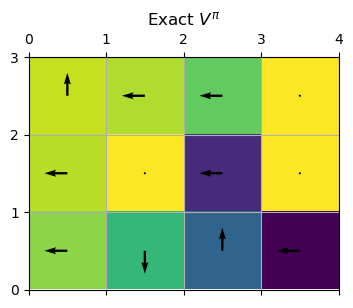

In [106]:
print_policy(policy_matrix, V_exact, title="Exact $V^{\pi}$")

In [107]:
valid_mask = (state_matrix == 0)

print("Maximum difference MC First Visit vs Exact:")
print(np.max(np.abs(V_mc_first[valid_mask] - V_exact[valid_mask])))

print("Maximum difference MC Every Visit vs Exact:")
print(np.max(np.abs(V_mc_every[valid_mask] - V_exact[valid_mask])))

print("Maximum difference TD(0) vs Exact:")
print(np.max(np.abs(V_td[valid_mask] - V_exact[valid_mask])))

Maximum difference MC First Visit vs Exact:
0.30972300192195235
Maximum difference MC Every Visit vs Exact:
0.14031057338342112
Maximum difference TD(0) vs Exact:
1.4210884381549391


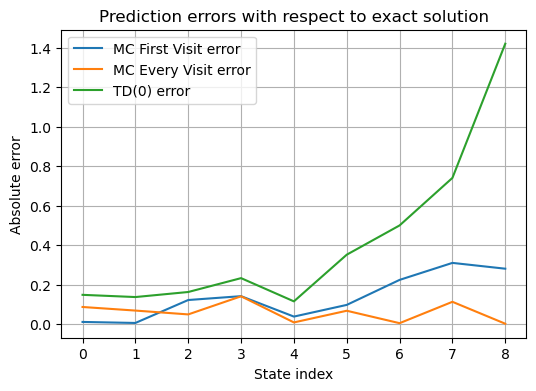

In [108]:
plt.figure(figsize=(6, 4))
plt.plot(np.abs((V_mc_first - V_exact)[valid_mask]).flatten(), label="MC First Visit error")
plt.plot(np.abs((V_mc_every - V_exact)[valid_mask]).flatten(), label="MC Every Visit error")
plt.plot(np.abs((V_td - V_exact)[valid_mask]).flatten(), label="TD(0) error")
plt.xlabel("State index")
plt.ylabel("Absolute error")
plt.title("Prediction errors with respect to exact solution")
plt.legend()
plt.grid()
plt.show()

# 5. On and Off Learning

## 5.1 Theory Section

In this section, the objective is no longer to evaluate a fixed policy, but to learn the optimal control policy.

To do so, we work with the action-value function Q(s,a), which measures the expected return when action a is taken in state s and the subsequent behavior follows a given policy.

Two learning algorithms are considered:

1. SARSA:
$Q(S,A) \leftarrow Q(S,A) + \alpha [R + \gamma Q(S',A') - Q(S,A)]$

This is an on-policy method because it learns the action-value of the same policy that is used to generate behavior.

2. Q-learning:
$Q(S,A) \leftarrow Q(S,A) + \alpha [R + \gamma \max_{a'} Q(S',a') - Q(S,A)]$

This is an off-policy method because it learns the optimal greedy value independently of the exploratory behavior policy.

The learned policy is extracted by choosing in each state the action with maximum Q-value.

## 5.2. Auxiliary Functions for Control

In [109]:
def epsilon_greedy_action(Q, state, epsilon=0.9):
    if np.random.rand() < epsilon:
        return np.argmax(Q[state[0], state[1], :])
    return np.random.choice(4)

def uniform_random_action():
    return np.random.choice(4)

def greedy_policy_from_Q(Q):
    policy = np.full(state_matrix.shape, -1.0)

    for i in range(state_matrix.shape[0]):
        for j in range(state_matrix.shape[1]):
            s = (i, j)

            if is_normal(s):
                policy[s] = np.argmax(Q[i, j, :])
            elif is_blocked(s):
                policy[s] = np.nan
            else:
                policy[s] = -1

    return policy

def value_from_Q(Q):
    V = np.zeros(state_matrix.shape)
    for i in range(state_matrix.shape[0]):
        for j in range(state_matrix.shape[1]):
            s = (i, j)
            if is_normal(s):
                V[s] = np.max(Q[i, j, :])
            else:
                V[s] = 0.0
    return V

## 5.3. Exercise 1 - SARSA with $\epsilon$-greedy

In [110]:
def sarsa(n_episodes=5000, epsilon=0.9, max_steps=500):
    Q = np.zeros((state_matrix.shape[0], state_matrix.shape[1], 4))
    visit_count = np.zeros_like(Q)
    episode_rewards = []

    for ep in range(1, n_episodes + 1):
        state = sample_start_state()
        action = epsilon_greedy_action(Q, state, epsilon)
        total_reward = 0.0

        for _ in range(max_steps):
            next_state, reward = sample_next_state(state, action)
            total_reward += reward

            visit_count[state[0], state[1], action] += 1
            alpha = 1.0 / visit_count[state[0], state[1], action]

            if is_terminal(next_state):
                td_target = reward
                Q[state[0], state[1], action] += alpha * (td_target - Q[state[0], state[1], action])
                break
            else:
                next_action = epsilon_greedy_action(Q, next_state, epsilon)
                td_target = reward + gamma * Q[next_state[0], next_state[1], next_action]
                Q[state[0], state[1], action] += alpha * (td_target - Q[state[0], state[1], action])

                state = next_state
                action = next_action

        episode_rewards.append(total_reward)

    return Q, episode_rewards

SARSA learned policy:
[[ 2.  3.  1. -1.]
 [ 1. nan  0. -1.]
 [ 0.  3.  3.  3.]]


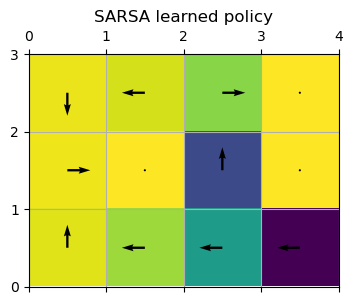

In [111]:
Q_sarsa, rewards_sarsa = sarsa(n_episodes=10000, epsilon=0.9)

policy_sarsa = greedy_policy_from_Q(Q_sarsa)
V_sarsa = value_from_Q(Q_sarsa)

print("SARSA learned policy:")
print(policy_sarsa)
print_policy(policy_sarsa, V_sarsa, title="SARSA learned policy")

In [112]:
def sarsa(n_episodes=5000, epsilon=0.9, max_steps=500):
    Q = np.zeros((state_matrix.shape[0], state_matrix.shape[1], 4))
    visit_count = np.zeros_like(Q)
    episode_rewards = []

    for ep in range(1, n_episodes + 1):
        state = sample_start_state()
        action = epsilon_greedy_action(Q, state, epsilon)
        total_reward = 0.0

        for _ in range(max_steps):
            next_state, reward = sample_next_state(state, action)
            total_reward += reward

            visit_count[state[0], state[1], action] += 1
            alpha = 1.0 / visit_count[state[0], state[1], action]

            if is_terminal(next_state):
                td_target = reward
                Q[state[0], state[1], action] += alpha * (td_target - Q[state[0], state[1], action])
                break
            else:
                next_action = epsilon_greedy_action(Q, next_state, epsilon)
                td_target = reward + gamma * Q[next_state[0], next_state[1], next_action]
                Q[state[0], state[1], action] += alpha * (td_target - Q[state[0], state[1], action])

                state = next_state
                action = next_action

        episode_rewards.append(total_reward)

    return Q, episode_rewards

## 5.4. Exercise 2 - Q-Learning with different exploration policies

In [113]:
def q_learning(n_episodes=5000, behavior="epsilon_greedy", epsilon=0.9, max_steps=500):
    Q = np.zeros((state_matrix.shape[0], state_matrix.shape[1], 4))
    visit_count = np.zeros_like(Q)
    episode_rewards = []

    for ep in range(1, n_episodes + 1):
        state = sample_start_state()
        total_reward = 0.0

        for _ in range(max_steps):
            if behavior == "uniform":
                action = uniform_random_action()
            elif behavior == "epsilon_greedy":
                action = epsilon_greedy_action(Q, state, epsilon)
            else:
                raise ValueError("Unknown behavior policy")

            next_state, reward = sample_next_state(state, action)
            total_reward += reward

            visit_count[state[0], state[1], action] += 1
            alpha = 1.0 / visit_count[state[0], state[1], action]

            if is_terminal(next_state):
                td_target = reward
            else:
                td_target = reward + gamma * np.max(Q[next_state[0], next_state[1], :])

            Q[state[0], state[1], action] += alpha * (td_target - Q[state[0], state[1], action])

            state = next_state

            if is_terminal(state):
                break

        episode_rewards.append(total_reward)

    return Q, episode_rewards

Q-learning with uniform exploration:
[[ 2.  3.  1. -1.]
 [ 1. nan  0. -1.]
 [ 0.  3.  3.  3.]]


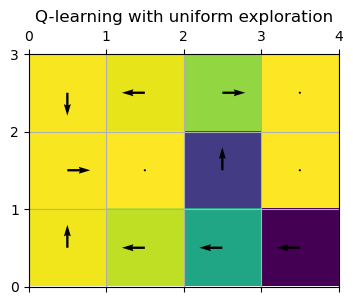

Q-learning with epsilon-greedy exploration:
[[ 2.  3.  1. -1.]
 [ 0. nan  0. -1.]
 [ 0.  3.  3.  3.]]


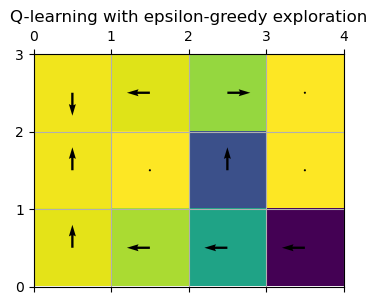

In [114]:
Q_uniform, rewards_uniform = q_learning(n_episodes=10000, behavior="uniform")
Q_eps, rewards_eps = q_learning(n_episodes=10000, behavior="epsilon_greedy", epsilon=0.9)

policy_uniform = greedy_policy_from_Q(Q_uniform)
policy_eps = greedy_policy_from_Q(Q_eps)

V_uniform = value_from_Q(Q_uniform)
V_eps = value_from_Q(Q_eps)

print("Q-learning with uniform exploration:")
print(policy_uniform)
print_policy(policy_uniform, V_uniform, title="Q-learning with uniform exploration")

print("Q-learning with epsilon-greedy exploration:")
print(policy_eps)
print_policy(policy_eps, V_eps, title="Q-learning with epsilon-greedy exploration")

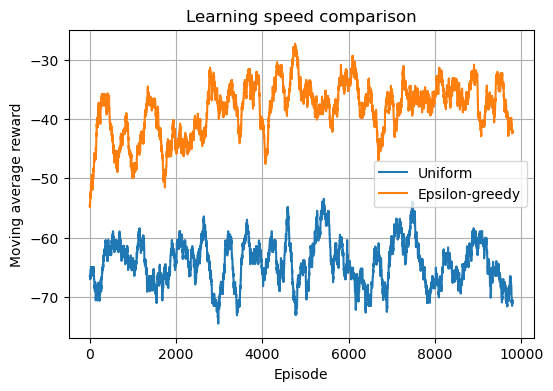

In [115]:
def moving_average(x, w=200):
    return np.convolve(x, np.ones(w) / w, mode='valid')

plt.figure(figsize=(6, 4))
plt.plot(moving_average(rewards_uniform, 200), label="Uniform")
plt.plot(moving_average(rewards_eps, 200), label="Epsilon-greedy")
plt.xlabel("Episode")
plt.ylabel("Moving average reward")
plt.title("Learning speed comparison")
plt.legend()
plt.grid()
plt.show()

## 5.5. Exercise 3 - Influence of gamma, epsilon and terminal reward

In [116]:
def run_parameter_study(gamma_values, epsilon_values, terminal_rewards, n_episodes=5000):
    results = []

    global gamma, reward_matrix

    original_gamma = gamma
    original_reward_matrix = reward_matrix.copy()

    for g in gamma_values:
        gamma = g

        for eps in epsilon_values:
            for terminal_reward in terminal_rewards:
                reward_matrix[0, 3] = 1.0
                reward_matrix[1, 3] = terminal_reward

                Q_sarsa_tmp, rewards_sarsa_tmp = sarsa(n_episodes=n_episodes, epsilon=eps)
                Q_q_tmp, rewards_q_tmp = q_learning(n_episodes=n_episodes, behavior="epsilon_greedy", epsilon=eps)

                policy_sarsa_tmp = greedy_policy_from_Q(Q_sarsa_tmp)
                policy_q_tmp = greedy_policy_from_Q(Q_q_tmp)

                results.append({
                    "gamma": g,
                    "epsilon": eps,
                    "terminal_reward": terminal_reward,
                    "policy_sarsa": policy_sarsa_tmp,
                    "policy_q_learning": policy_q_tmp,
                    "avg_reward_sarsa": np.mean(rewards_sarsa_tmp[-200:]),
                    "avg_reward_q_learning": np.mean(rewards_q_tmp[-200:])
                })

    gamma = original_gamma
    reward_matrix = original_reward_matrix.copy()

    return results

In [117]:
study_results = run_parameter_study(
    gamma_values=[0.5, 0.9, 0.99],
    epsilon_values=[0.6, 0.9],
    terminal_rewards=[-20, -100],
    n_episodes=3000
)

for res in study_results:
    print("--------------------------------------------------")
    print(f"gamma = {res['gamma']}, epsilon = {res['epsilon']}, terminal reward = {res['terminal_reward']}")
    print("SARSA policy:")
    print(res["policy_sarsa"])
    print("Q-learning policy:")
    print(res["policy_q_learning"])
    print("Average final reward SARSA:", res["avg_reward_sarsa"])
    print("Average final reward Q-learning:", res["avg_reward_q_learning"])

--------------------------------------------------
gamma = 0.5, epsilon = 0.6, terminal reward = -20
SARSA policy:
[[ 3.  3.  1. -1.]
 [ 0. nan  0. -1.]
 [ 3.  3.  3.  3.]]
Q-learning policy:
[[ 1.  1.  1. -1.]
 [ 0. nan  2. -1.]
 [ 0.  3.  3.  3.]]
Average final reward SARSA: -9.370600000000001
Average final reward Q-learning: -7.9548000000000005
--------------------------------------------------
gamma = 0.5, epsilon = 0.6, terminal reward = -100
SARSA policy:
[[ 3.  3.  1. -1.]
 [ 3. nan  0. -1.]
 [ 2.  3.  3.  3.]]
Q-learning policy:
[[ 0.  3.  1. -1.]
 [ 1. nan  0. -1.]
 [ 0.  3.  3.  3.]]
Average final reward SARSA: -50.285
Average final reward Q-learning: -44.12520000000001
--------------------------------------------------
gamma = 0.5, epsilon = 0.9, terminal reward = -20
SARSA policy:
[[ 2.  3.  1. -1.]
 [ 3. nan  0. -1.]
 [ 0.  3.  3.  3.]]
Q-learning policy:
[[ 1.  1.  1. -1.]
 [ 0. nan  0. -1.]
 [ 0.  3.  2.  3.]]
Average final reward SARSA: -8.3618
Average final reward Q-le